NumPy Weights: [0.1 0.1] -0.1


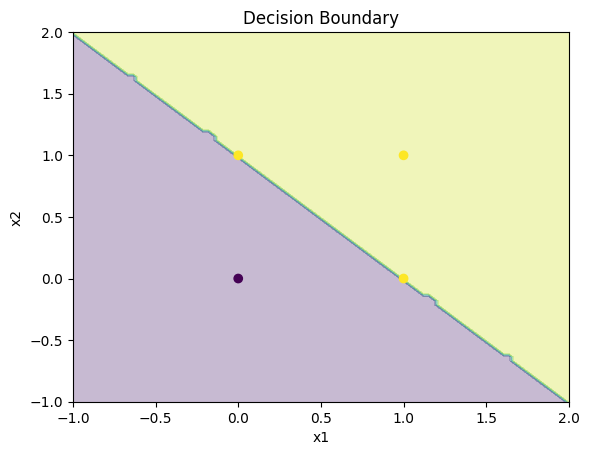

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def H(z):
    return np.where(z >= 0, 1, 0)


def output(x, w, b):
    return H(np.dot(w, x) + b)


def p_learn(X, Y, w, b, eta, epochs):
    for _ in range(epochs):
        for x, y in zip(X, Y):
            y_pred = output(x, w, b)
            error = y - y_pred

            w = w + eta * error * x
            b = b + eta * error

    return w, b


def plot_decision_boundary(X, Y, w, b):
    X = np.array(X)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = H(w[0] * xx + w[1] * yy + b)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.title("Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


# Test OR dataset
X = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
Y_OR = np.array([1, 1, 1, 0])

w = np.zeros(2)
b = 0

w, b = p_learn(X, Y_OR, w, b, eta=0.1, epochs=10)

print("NumPy Weights:", w, b)
plot_decision_boundary(X, Y_OR, w, b)